# Homework Assignment



> Oskar Krawczyk, AIML22 Group 3







---

In this homework assignment, we will focus on the topics covered during the week 3 of Lady Margaret Hall Summer Programme. This time, we will explore the field of self-supervised learning for computer vision, with an emphasis on CLIP models.

For the practical part of this task, we will work with [TinyImageNet](https://cs231n.stanford.edu/reports/2017/pdfs/930.pdf) dataset, which is a scaled-down version of the ImageNet dataset. Using this, we will evaluate CLIP's zero-shot classification performance. This will involve specific text prompts for each image class based on the dataset's words file and their text embeddings. We will then perform classification using similarily matching between the text and image embeddings, followed by evaluation and metrics analysis. Finally, we will implement the main task - Image Search Engine. We will build functionalities to search for relevant visual data using both text-to-image and image-to-image queries.


In the following notebook, I split my solution into six separate sections - Part 1, 2, 3, 4, 5, 6 - which follow the convention used in the initial [ImageSearch_Clip.ipynb](https://www.dropbox.com/scl/fi/5tchk22pf8zatb1on5fnf/Image_Search_with_CLIP.ipynb?rlkey=9jzl0on4chjdtnb8xlckmy2s2&st=hbfegt3d&e=1&dl=0) notebook. Each section includes the code as part of my solution as well as a brief explanation of certain concepts not mentioned during lectures/seminars. At the end of this notebook, I also denote resources used to complete and/or improve the final results and additional steps I have taken (beyond the required ones) to complete the notebook.


---



## Part 1

In this section we first import all necessary libraries into a single cell. The reason is that in the future if someone tries to access the very same code, it is preferable to keep it in the single cell instead of having imports scattered across the entire notebook. Then, we set up the notebook by specifying settings for plotting (matplotlib/seaborn), device and verify versions of libraries imported. Finally, we download the dataset to later explore its structure and content.

It is recommended you run the following cell since depending on the environment and settings, some packages might not be included in the standard setup (especially, tinyimagenet and transformers libraries). While debugging, removing -qq might be beneficial since this flag displays critical errors only.

In [1]:
!pip -qq install tinyimagenet transformers

#### Library imports

In [2]:
import os
import tqdm
import random
import textwrap
import shutil

import numpy as np
import pandas as pd

import torch
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import seaborn as sns

from tinyimagenet import TinyImageNet
from transformers import CLIPModel, CLIPProcessor

from torch.utils.data import DataLoader
from PIL import Image
from collections import Counter

#### Notebook setup

Here, we configure the default settings for the notebook. First, we set the random seed to ensure the reproducibility of the results. Then, based on my preferences, we configure the default settings for matplotlib and seaborn packages to ensure consistent plotting. Finally, we display information regarding the imported libraries - if any methods change in the future versions of these packages, this is a reference point.

In [4]:
SEED = 2026

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams["figure.figsize"] = (8, 8)
sns.set_style("darkgrid")

print("---- Notebook setup info ----")
print(f"Device:         {device}")
print(f"PyTorch:        {torch.__version__}")
print(f"Torchvision:    {torchvision.__version__}")
print(f"Numpy:          {np.__version__}")
print(f"Pandas:         {pd.__version__}")

---- Notebook setup info ----
Device:         cuda
PyTorch:        2.11.0+cu128
Torchvision:    0.26.0+cu128
Numpy:          2.0.2
Pandas:         2.2.2


#### Explore the dataset

Now, we first download the TinyImageNet dataset, specifically using the validation split. Then, we first examine the sturcture of the dataset - its statistics, applied transformations and number of samples. Finally, we visualise five random samples with their corresponding labels.

In [5]:
dataset = TinyImageNet("tiny-imagenet", split = "val")

100%|██████████| 248M/248M [00:58<00:00, 4.27MB/s]


In [6]:
print("--------- Dataset information ---------\n")

print(f"Dataset root path: {dataset.root}\n")

print(f"Transformations: {dataset.transform}\n")

print(f"Statistics")
print(f"- Mean: {dataset.mean}")
print(f"- Std:  {dataset.std}\n")

print(f"Number of samples: {len(dataset)}\n")
print(f"Number of classes: {len(dataset.classes)}")

--------- Dataset information ---------

Dataset root path: tiny-imagenet/tiny-imagenet-200/val

Transformations: ToTensor()

Statistics
- Mean: [0.485, 0.456, 0.406]
- Std:  [0.229, 0.224, 0.225]

Number of samples: 10000

Number of classes: 200


As we can see, when loading TinyImageNet we only perform a standard transformation to a tensor and use exactly the same normalisation statistics as the original ImageNet. Furthermore, as the name "Tiny" suggests, the dataset is much smaller - it contains only 200 classes compared to ImageNet's 1000, the number of samples is reduced to 10000 with images of smaller resolution - 64x64.

Before me move on to visualising the samples, we will take a closer look at a single image from our dataset. First of all, we will make sure that its size is indeed 64x64, but I would especially like to draw attention to the label that can be assigned to a single image and what data type it is. This will be helpful in further analysis of the dataset, visualising the samples and eventually evaluating the model itself.

In [7]:
single_sample = dataset[150]

print(f"--------- Sample image information ---------\n")
print(f"Image shape:        {list(single_sample[0].shape)}")
print(f"Class index:        {single_sample[1]}")
print(f"Class name(s):      {dataset.idx_to_words[single_sample[1]]}")

--------- Sample image information ---------

Image shape:        [3, 64, 64]
Class index:        3
Class name(s):      ['tailed frog', ' bell toad', ' ribbed toad', ' tailed toad', ' Ascaphus trui']


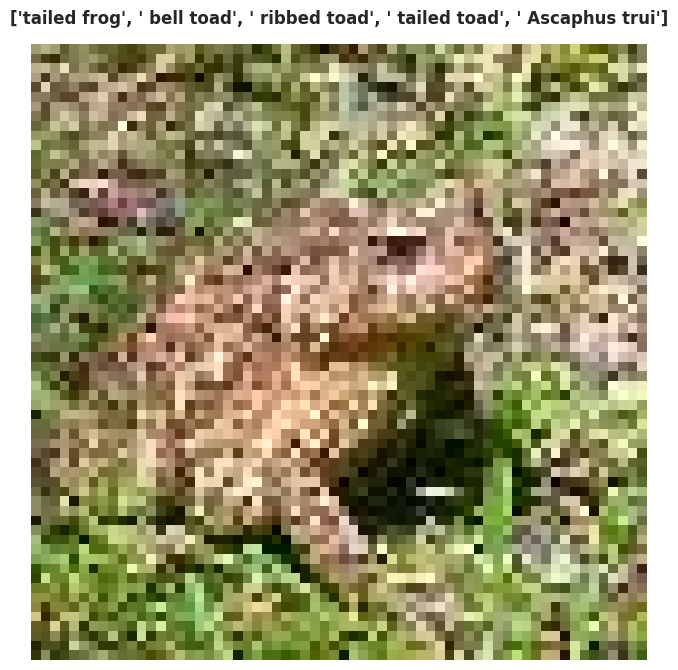

In [8]:
image, label = single_sample

plt.imshow(image.permute(1, 2, 0))
plt.title(f"{dataset.idx_to_words[label]}", fontweight = "bold", pad = 15)
plt.axis("off")
plt.show()

As we can see, labels of the images in our dataset are of list type, in particular an image can have various labels assigned. On how to deal with it during evaluation, we will elaborate further in the upcoming sections, but for now in the visualisation below we will assume that the first two elements in the list will be our label (otherwise visualisation might be distorted).

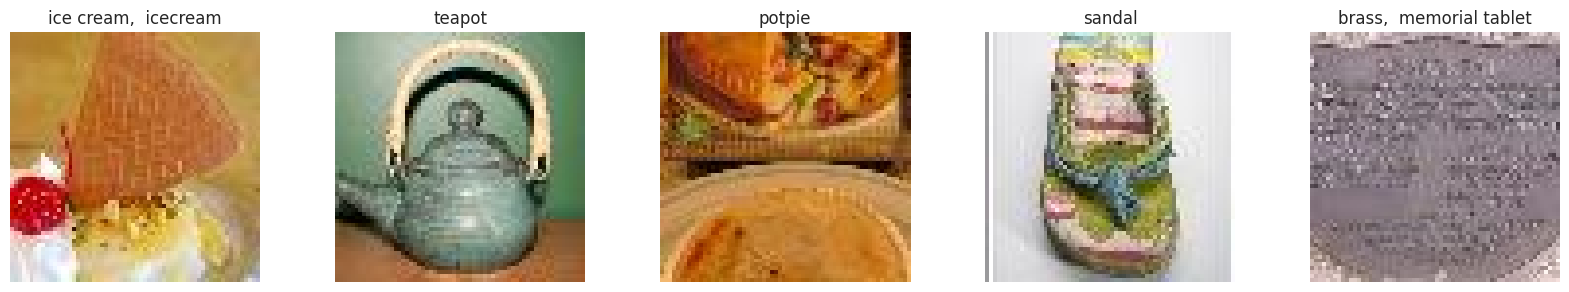

In [11]:
NUM_SAMPLES = 5

random_indicies = [random.randint(0, len(dataset) - 1) for _ in range(NUM_SAMPLES)]

fig, axes = plt.subplots(nrows = 1, ncols = NUM_SAMPLES, figsize = (20, 4))
plt.subplots_adjust(wspace = .3)

for i in range(NUM_SAMPLES):
    image, label = dataset[random_indicies[i]]

    named_label = dataset.idx_to_words[label]
    label_str = ", ".join(named_label[:2])
    wrapped_label = "\n".join(textwrap.wrap(label_str, width = 30))

    axes[i].imshow(image.permute(1, 2, 0).cpu())
    axes[i].set_title(f"{wrapped_label}")
    axes[i].axis("off")

Before we proceed with the feature extraction, we will explore the data a bit further to better understand the dataset. One important step is checking how the samples are distributed across different classes, since an imbalanced dataset can affect the model significantly (see assignment 1). To do so, we will first calculate the number of samples in each class and later visualise the distribution.

------ Dataset information ------
Minimum number of samples: 50
Maximum number of samples: 50
Mean number of samples:    50.00



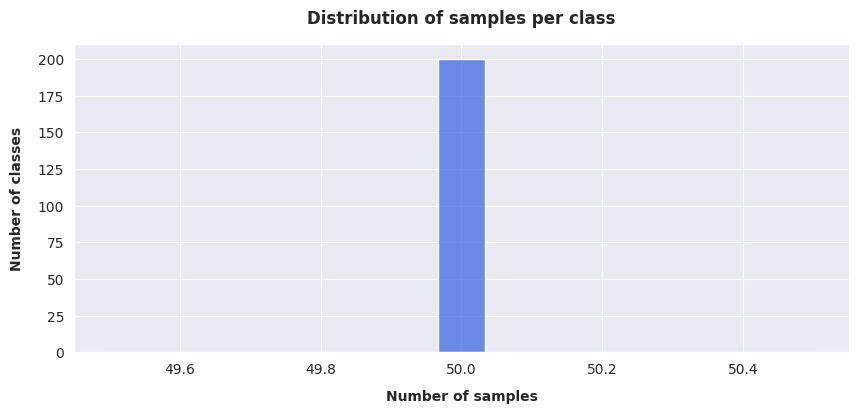

In [13]:
all_labels = [label for _, label in dataset]

label_counts = Counter(all_labels)

df_counter = pd.DataFrame.from_dict(label_counts, orient = "index", columns = ["count"])
df_counter.index.name = "class_idx"
df_counts = df_counter.reset_index()

min_samples = df_counts["count"].min()
max_samples = df_counts["count"].max()
mean_samples = df_counts["count"].mean()

print("------ Dataset information ------")
print(f"Minimum number of samples: {min_samples}")
print(f"Maximum number of samples: {max_samples}")
print(f"Mean number of samples:    {mean_samples:.2f}\n")

fig, ax = plt.subplots(figsize = (10, 4))
sns.histplot(data = df_counter, x = "count", bins = 15, color = "royalblue", ax = ax)
ax.set_title("Distribution of samples per class", fontweight = "bold", pad = 15)
ax.set_xlabel("Number of samples", fontweight = "bold", labelpad = 10)
ax.set_ylabel("Number of classes", fontweight = "bold", labelpad = 10)
plt.show()

As we can see, all classes are distributed evenly, with 50 samples of each of 200 classes. Having said that, we can now proceed to Part 2 in which we will finally load the model, processor used to implement the Image Search Engine.

## Part 2

In this section we will load the pre-trained CLIP model together with its corresponding processor. Although many implementations use OpenAI's [CLIP-ViT-B-32 model](https://huggingface.co/openai/clip-vit-base-patch32), I tested several different CLIP variants to find the one that performs best for the following tasks. Specifically, I did compare models such as **CLIP-ViT-B-32, CLIP-ViT-L-14 and CLIP-ViT-L-14-336** before eventually selecting [LAION/CLIP-ViT-H-14-laion2B-s32B-b79K](https://huggingface.co/laion/CLIP-ViT-H-14-laion2B-s32B-b79K) which consistently achieved the best results in both zero-shot classification and image retrieval.

To better understand the model, we will look closer at its name:



*   ViT-H - Vision Transformer Huge, which means that is has a larger capacity than the base and large version, what we will see looking at its parameters.
*   14 - means that each input image is patchified into 14x14 pixel boxes.
*   LAION-2B-s32B-b79K means that it was trained on the LAION-2B dataset, which consists of about two billion image-text pairs and was trained on about 32B samples (batch_size ~ 79,000).

Finally, we will initialise the model and its processor. We will also calculate and display the number of paramters in both vision and text encoders to illustrate the scale and distribution of the whole architecture.


![CLIP Architecture](https://github.com/openai/CLIP/raw/main/CLIP.png)

For more details check [Learning Transferable Visual Models From Natural Language Supervision](https://arxiv.org/pdf/2103.00020) paper.

In [14]:
ARCHITECTURE = "laion/CLIP-ViT-H-14-laion2B-s32B-b79K"

model = CLIPModel.from_pretrained(ARCHITECTURE).to(device)
processor = CLIPProcessor.from_pretrained(ARCHITECTURE)

config.json:   0%|          | 0.00/4.72k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.94GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/910 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/904 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

If you want to see the whole picture of the model, that is the architecture, layer by layer then uncomment the following line.

**Note**: all layers with their parameters will be printed which might clutter the notebook (visually).

In [15]:
# print(model)

Instead, we will display (by default) what the architecture of the model is and how many parameters is has since it will significantly determine the following phase in Part 3.

In [16]:
model_parameters = sum(param.numel() for param in model.parameters())

vision_parameters = sum(param.numel() for param in model.vision_model.parameters())
text_parameters = sum(param.numel() for param in model.text_model.parameters())

print("------------- Model information -------------\n")

print(f"Architecture:           {ARCHITECTURE}\n")
print(f"Number of parameters:   {model_parameters:,}\n")
print(f"Vision parameters:      {vision_parameters:,}\n")
print(f"Text parameters:        {text_parameters:,}\n")

------------- Model information -------------

Architecture:           laion/CLIP-ViT-H-14-laion2B-s32B-b79K

Number of parameters:   986,109,441

Vision parameters:      630,766,080

Text parameters:        352,984,064



## Part 3

In this section we define a function to extract and process CLIP embeddings for the entire dataset. First, we set up a dataloader to handle the batching efficiently - because TinyImageNet images are (what we saw in Part 1) 64x64 pixels and the pre-trained model expects 224x224 inputs, we resize the image tensors before passing them directly to the model - Otherwise, the model's positional embeddings would fail to process the images correctly.

**Note**: We have seen that the TinyImageNet dataset uses default ImageNet normalisation statistics. However, in our case we have to override them when extracting features with CLIP - it was trained on a different dataset, so using ImageNet's stats degraded the quality of the embeddings therefore lowering the accuracy.

In [17]:
@torch.no_grad()
def extract_embeddings(model, dataset, device, batch_size):
    '''
    Function to extract CLIP embeddings for the entire dataset.

    Args:
        model: CLIP model.
        dataset: TinyImageNet dataset.
        device: Device to run the model on.
        batch_size: Batch size for the dataloader.

    Returns:
        embeddings: Dictionary containing image and text embeddings.
    '''

    CLIP_MEAN = [0.48145466, 0.4578275, 0.40821073]
    CLIP_STD = [0.26862954, 0.26130258, 0.27577711]

    transformations = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Normalize(mean = CLIP_MEAN, std = CLIP_STD)
    ])

    model.eval()

    loader = DataLoader(dataset, batch_size = batch_size, shuffle = False)

    embeddings, labels = [], []

    for images, label in tqdm.tqdm(loader, desc = "Extracting"):
        images = transformations(images).to(device)

        outputs = model.vision_model(pixel_values = images)
        pool = outputs.pooler_output

        embed = model.visual_projection(pool)
        embed = embed / embed.norm(dim = -1, keepdim = True, p = 2)

        embeddings.append(embed.cpu())

        labels.append(label)

    embeddings = torch.cat(embeddings, dim = 0)
    labels = torch.cat(labels, dim = 0)

    return {"embeddings": embeddings, "labels": labels}

In [18]:
embeddings = extract_embeddings(model, dataset, device, batch_size = 128)

Extracting: 100%|██████████| 79/79 [15:36<00:00, 11.85s/it]


In [19]:
embeddings_tensor = embeddings["embeddings"]
labels_tensor = embeddings["labels"]

In [20]:
print("------------- Embedding information -------------\n")

print(f"Embeddings shape:           {list(embeddings_tensor.shape)}\n")
print(f"Labels shape:               {list(labels_tensor.shape)}\n")

torch.save(embeddings, "tinyimagenet_embeddings.pt")

------------- Embedding information -------------

Embeddings shape:           [10000, 1024]

Labels shape:               [10000]



As we can see, the extraction process was completed successfully. It is worth noting that the primary reason for performing such extraction is to translate the raw images provided in the dataset into a shared latent space. This in turn will allow us to efficiently retrieve images in the upcoming sections by comparing them against text or image queries using a simple tools to measure similarity.

With that being said, we can now move on to Part 4 in which we will perform zero-shot classification.

## Part 4

In this section we takle zero-shot classification - that is we are going to classify validation images into 200 categories without having trained the model on this dataset specifically. Before we do that, we need to handle data formatting first - TinyImageNet stores its classes as WordNet ids, which cannot be passed to our encoder (they would be meaningless). That is why to actually start working with the provided dataset we need to convert them into meaningful human-like names. We then perform two approaches which vary on the specified prompts. The first one aims to "blindly" use a single, standarised prompt while the second one aims to recreate prompts used in the original CLIP paper.

#### First approach

In this approach we take the very first name associated with each class and we then place it into a standard template - "a photo of a {class_name}". We then run these prompts through text encoder, calculate the similarities and take our predictions based on the highest score. As you will notice, accuracy achieved in this method is not the highest since the prompts' template is very standard and completely omits scenarios with multiple labels.

In [21]:
words_path = os.path.join("tiny-imagenet/tiny-imagenet-200", "words.txt")

words_dict = {}
with open(words_path, "r") as file:
    for line in file:
        parts = line.strip().split("\t")
        if len(parts) == 2:
            word, idx = parts
            words_dict[idx] = idx.split(",")[0].strip()

In [22]:
prompts = []
for i in range(len(dataset.classes)):
    eng = dataset.idx_to_words[i][0].strip()
    prompts.append(f"a photo of a {eng}")

text_in = processor(text = prompts, return_tensors = "pt", padding = True).to(device)
model.eval()

with torch.no_grad():
    text_embed = model.text_model(**text_in)
    pool = text_embed.pooler_output
    text_embed = model.text_projection(pool)
    text_embed = text_embed / text_embed.norm(dim = -1, keepdim = True, p = 2)
    text_embed = text_embed.cpu()

similarities = torch.matmul(embeddings_tensor, text_embed.T)
preds = similarities.argmax(dim = 1)

accuracy = (preds == labels_tensor).float().mean().item()

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 77.07%


#### Second approach

Here on the other hand, instead of relying on a single generic sentence we create a list of many different contexts. Furthermore, instead of picking only the first label, we generate the prompts for every possible label of a given class. We then enocde all these variations, stack them together and calculate the average achieved by all possibilities. Thanks to that we can indeed observe a slight improvement which has also been described in the official CLIP paper.

**Note**: there are many ways to encode multiple labels, but the one below worked best for me.


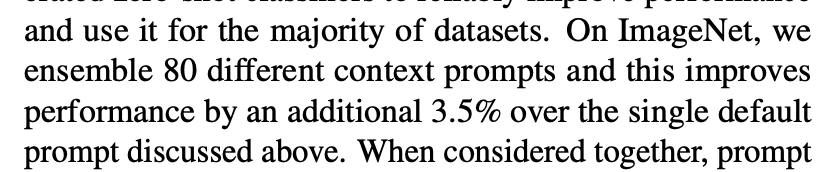


The above-mentioned strategy was inspired by the official CLIP paper -[Source]("https://arxiv.org/pdf/2103.00020")

In [26]:
templates = [
    'a bad photo of a {}.',
    'a photo of many {}.',
    'a sculpture of a {}.',
    'a photo of the hard to see {}.',
    'a low resolution photo of the {}.',
    'a high resolution photo of the {}.',
    'graffiti of a {}.',
    'a bad photo of the {}.',
    'a cropped photo of the {}.',
    'a photo of a hard to see {}.',
    'a bright photo of a {}.',
    'the origami {}.',
    'the {} in a video game.',
    'a sketch of a {}.',
    'a photo of a clean {}.',
    'a photo of a dirty {}.',
    'a dark photo of the {}.',
    'a light photo of the {}.',
    'a close-up photo of a {}.',
    'a painting of the {}.',
    'a painting of a {}.',
    'a pixelated photo of the {}.',
    'a sculpture of the {}.',
    'a bright photo of the {}.',
    'a blurry photo of the {}.',
    'a photo of a strange {}.',
    'a photo of the strange {}.',
    'a cute photo of {}',
    'a good photo of a {}.',
    'a photo of the large {}.',
    'a photo of the small {}.',
    'a photo of the {}.',
    'a good photo of the {}.',
    'a rendering of the {}.',
    'a {} in a video game.',
    'a photo of one {}.',
    'a doodle of a {}.',
    'a close-up photo of the {}.',
    'a photo of a {}.',
    'a drawing of a {}.',
    'a photo of my {}.',
    'the plastic {}.',
    'a photo of the cool {}.',
    'a {}',
    'the {}',
    'the toy {}.',
    'a photo of the clean {}.',
    'a sketch of the {}.',
    'a photo of a cool {}.',
    'a black and white photo of the {}.',
    'a drawing of the {}.',
    'a photo of the nice {}.',
]

model.eval()
weights = []

with torch.no_grad():
    for i in tqdm.tqdm(range(len(dataset.classes))):
        class_names = [name.strip() for name in dataset.idx_to_words[i]]

        class_embeds = []
        for class_name in class_names:
            prompts = [template.format(class_name) for template in templates]
            text_in = processor(text = prompts, return_tensors = "pt", padding = True).to(device)

            text_embed = model.text_model(**text_in)
            pool = text_embed.pooler_output
            text_embed = model.text_projection(pool)
            text_embed = text_embed / text_embed.norm(dim = -1, keepdim = True, p = 2)

            class_embeds.append(text_embed)

        class_embeds = torch.cat(class_embeds, dim = 0)
        class_embeds = class_embeds.mean(dim = 0)

        class_embeds = class_embeds / class_embeds.norm(dim = -1, keepdim = True, p = 2)
        weights.append(class_embeds.cpu())

text_embed = torch.stack(weights, dim = 0)
similarities = torch.matmul(embeddings_tensor, text_embed.T)
preds = similarities.argmax(dim = 1)

accuracy = (preds == labels_tensor).float().mean().item()

print(f"Accuracy: {accuracy * 100:.2f}%")

100%|██████████| 200/200 [01:16<00:00,  2.63it/s]


Accuracy: 78.48%


#### Further evaluation

To examine the results further, we will calculate the top5-accuracy. Since classes can be visually similar (e.g. red and pink cars), checking if the correct label falls within the model's top 5 predictions gives us a better understanding of model's capabilities.

Additionally, we will analyse per-class accuracy to see where our model struggles most. In particular, we will display top 3 best and worst performing classes since using other methods like a confusion matrix for 200 classes would not be the best option for our purposes.

In [27]:
top_predictions = similarities.topk(k = 5, dim = 1).indices
top_true = (top_predictions == labels_tensor.unsqueeze(1)).any(dim = 1)
top5_accuracy = top_true.float().mean().item()

print(f"Top-5 accuracy: {top5_accuracy * 100:.2f}%")

Top-5 accuracy: 92.81%


In [28]:
class_correct = torch.zeros(len(dataset.classes))
class_total = torch.zeros(len(dataset.classes))

for i in range(len(labels_tensor)):
    label = labels_tensor[i]
    prediction = preds[i]

    if label == prediction:
        class_correct[label] += 1
    class_total[label] += 1

class_accuracy = class_correct / class_total

sorted_accuracy, sorted_indices = torch.sort(class_accuracy, descending = True)

print("---- Top 3 best performing classes ----")
for i in range(3):
    index = sorted_indices[i].item()
    name = dataset.idx_to_words[index][0]
    print(f"{i + 1}. {name} - {sorted_accuracy[i] * 100:.2f}%")

print("\n---- Top 3 worst performing classes ----")
for i in range(3):
    index = sorted_indices[-i - 1].item()
    name = dataset.idx_to_words[index][0]
    print(f"{i + 1}. {name} - {sorted_accuracy[-i - 1] * 100:.2f}%")

---- Top 3 best performing classes ----
1. school bus - 100.00%
2. goldfish - 100.00%
3. monarch - 98.00%

---- Top 3 worst performing classes ----
1. cliff - 16.00%
2. Egyptian cat - 28.00%
3. syringe - 36.00%


The Top5 accuracy of over 92% is a really good result for a zero-shot model on this dataset. It demonstrates that even when our model failts to perfectly predict the class of image, it manages to correctly place them within the closes "neighbours" which shows that the model generalised properly. We can now move to the implementation of the main task in this notebook.

## Part 5

As it was mentioned at the very beginning, we will now implement the Image Search Engine. Because of the extraction performed in Part 3, searching will now be very efficient - we will calculate similarity (dot product) between the queries. To do so, we implement the following methods. This section mainly aims to prepare for the further analysis and usage in the last part where we will harness these functions to visualise custom queries.

In [29]:
CLIP_MEAN = [0.48145466, 0.4578275, 0.40821073]
CLIP_STD = [0.26862954, 0.26130258, 0.27577711]

transformations = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(mean = CLIP_MEAN, std = CLIP_STD)
])

#### Text-to-Image search

Here we pass a user-defined text/prompt through the text encoder and find the visual embeddings that align most closely with it.

In [30]:
def text_image(query, model, processor, device, image_embedding, k = 5):
    '''
    Function to perform text-image search.

    Args:
        query: Text query.
        model: CLIP model.
        processor: CLIP processor.
        device: Device to run the model on.
        image_embedding: Image embeddings.
        k: Number of top results to return. (default: 5)

    Returns:
        topk_scores: Top k scores.
        topk_indices: Top k indices.
    '''

    model.eval()

    with torch.no_grad():
        text = processor(text = [query], return_tensors = "pt", padding = True).to(device)
        text_embed = model.text_model(**text)
        text_embed = model.text_projection(text_embed.pooler_output)

        text_embed = text_embed / text_embed.norm(dim = -1, keepdim = True, p = 2)
        text_embed = text_embed.cpu()

        similarities = torch.matmul(image_embedding, text_embed.T).squeeze()
        topk_scores, topk_indices = torch.topk(similarities, k = k)

    return topk_scores, topk_indices

#### Image-to-Image search

Here, on the other hand, we take a query image, pass it through the vision encoder using CLIPProcessor and then retrieve similar images from the dataset.

In [31]:
def image_image(query, model, device, image_embedding, k = 5):
    '''
    Function to perform image-image search.

    Args:
        query: Image query.
        model: CLIP model.
        device: Device to run the model on.
        image_embedding: Image embeddings.
        k: Number of top results to return.

    Returns:
        topk_scores: Top k scores.
        topk_indices: Top k indices.
    '''

    model.eval()

    with torch.no_grad():
        query = transformations(query).unsqueeze(0).to(device)
        query_embed = model.vision_model(pixel_values = query)
        query_embed = model.visual_projection(query_embed.pooler_output)

        query_embed = query_embed / query_embed.norm(dim = -1, keepdim = True, p = 2)
        query_embed = query_embed.cpu()

        similarities = torch.matmul(image_embedding, query_embed.T).squeeze()
        topk_scores, topk_indices = torch.topk(similarities, k = k)

    return topk_scores, topk_indices

In [32]:
def visualise_search(dataset, topk_scores, topk_indices, query_txt = None, query_img = None):
    '''
    Function to visualise search results.

    Args:
        dataset: TinyImageNet dataset.
        topk_scores: Top k scores.
        topk_indices: Top k indices.
        query_txt: Text query.
        query_img: Image query.
    '''

    k = len(topk_indices)

    num_cols = k + 1 if query_img is not None else k

    fig, axes = plt.subplots(nrows = 1, ncols = num_cols, figsize = (20, 4))
    plt.subplots_adjust(wspace = .4)

    offset = 0

    if query_img is not None:
        query_vis = torch.clamp(query_img, 0, 1)
        axes[0].imshow(query_vis.permute(1, 2, 0).cpu())
        axes[0].set_title(f"Query: {query_txt}", fontweight = "bold", pad = 15)
        axes[0].axis("off")
        offset = 1

    if query_txt is not None:
        axes[0].set_title(f"Query: {query_txt}", fontweight = "bold", pad = 15)

    for i in range(k):
        idx = topk_indices[i]
        score = topk_scores[i]

        image, label = dataset[idx]

        label_name = dataset.idx_to_words[label][0].strip()
        wrapped_label = "\n".join(textwrap.wrap(label_name, width = 25))

        image_vis = torch.clamp(image, 0, 1)
        axes[i + offset].imshow(image_vis.permute(1, 2, 0).cpu())
        axes[i + offset].set_title(f"Label: {wrapped_label}\nScore: {score:.4f}", fontweight = "bold", pad = 15)
        axes[i + offset].axis("off")

    plt.tight_layout()
    plt.show()

#### Examples

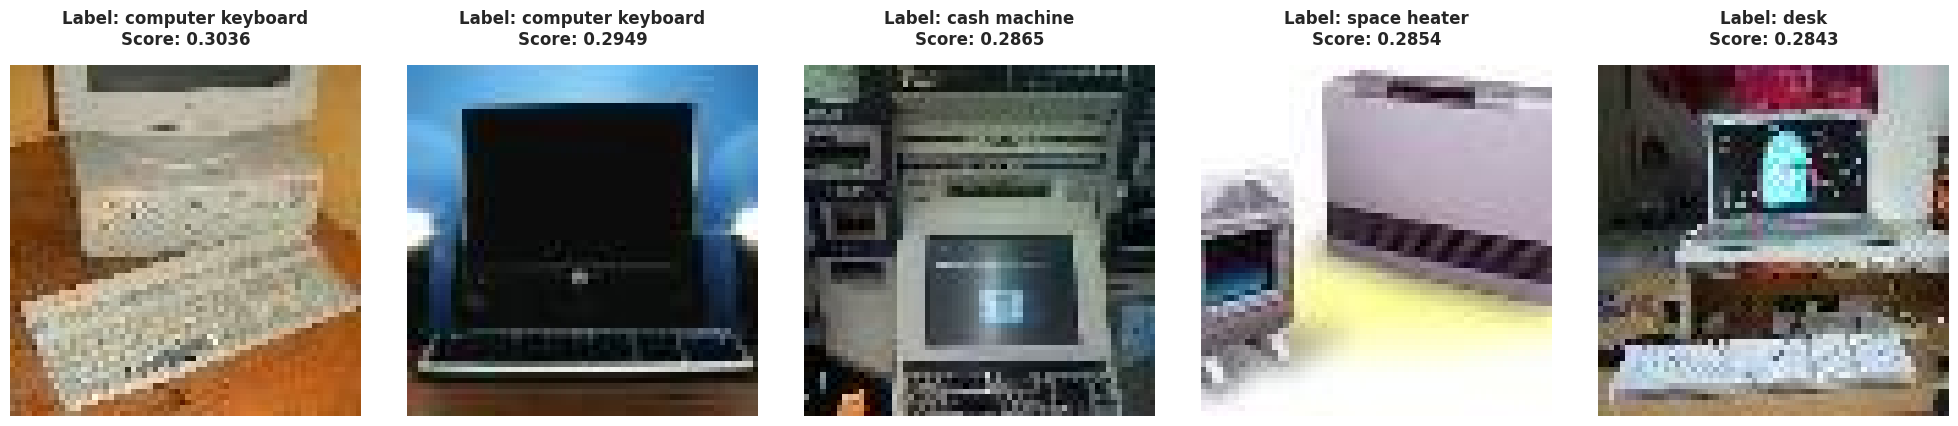

In [58]:
text_query = "a computer"
scores, indices = text_image(text_query, model, processor, device, embeddings_tensor)

visualise_search(dataset, scores, indices, query_txt = text_query)

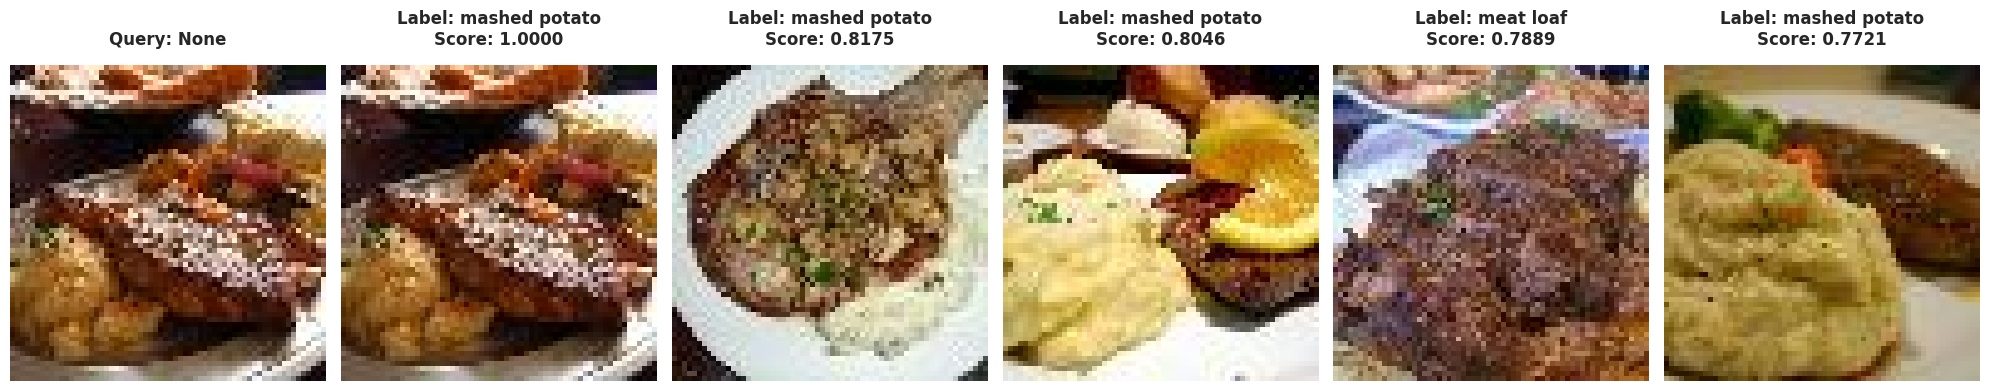

In [59]:
query_index = random.randint(0, len(dataset) - 1)
query_image, query_label = dataset[query_index]

scores, indices = image_image(query_image, model, device, embeddings_tensor)

visualise_search(dataset, scores, indices, query_img = query_image)

## Part 6

In this section we finally put the implemented Image Search Engine to the test using out-of-distribution queries. To do so, we will use functions implemented in the previous section and below I show sample queries that worked really well while I was playing with the notebook itself.

#### Text to Image

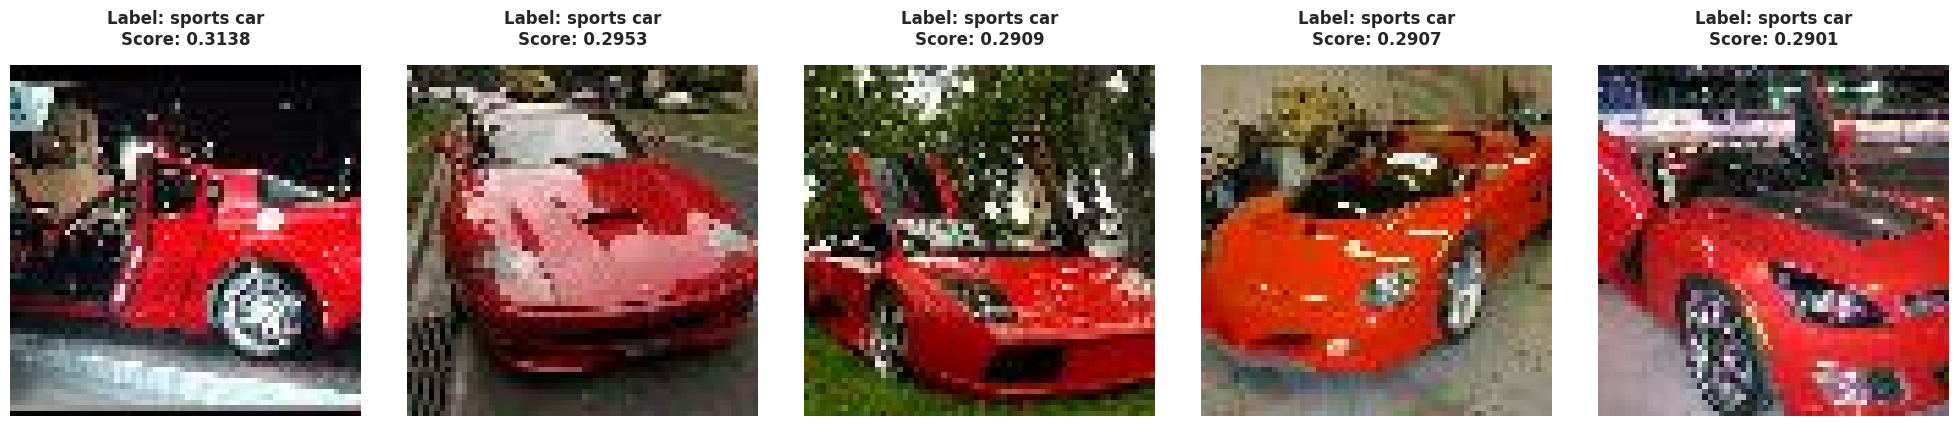

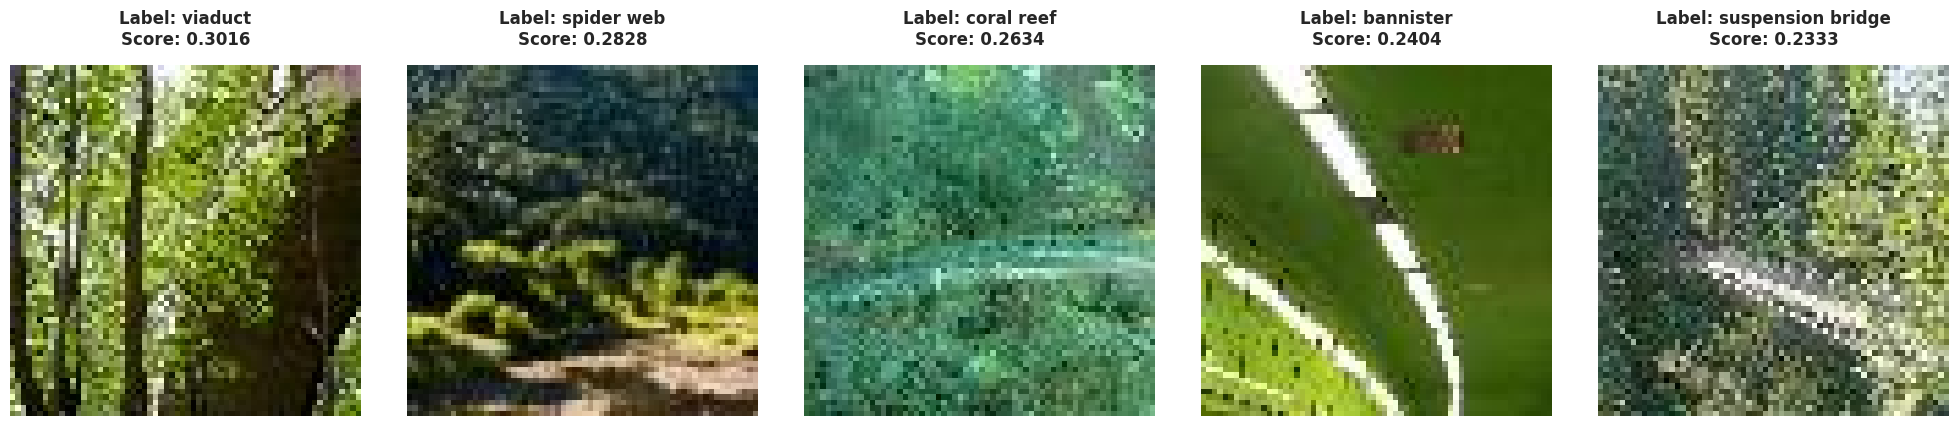

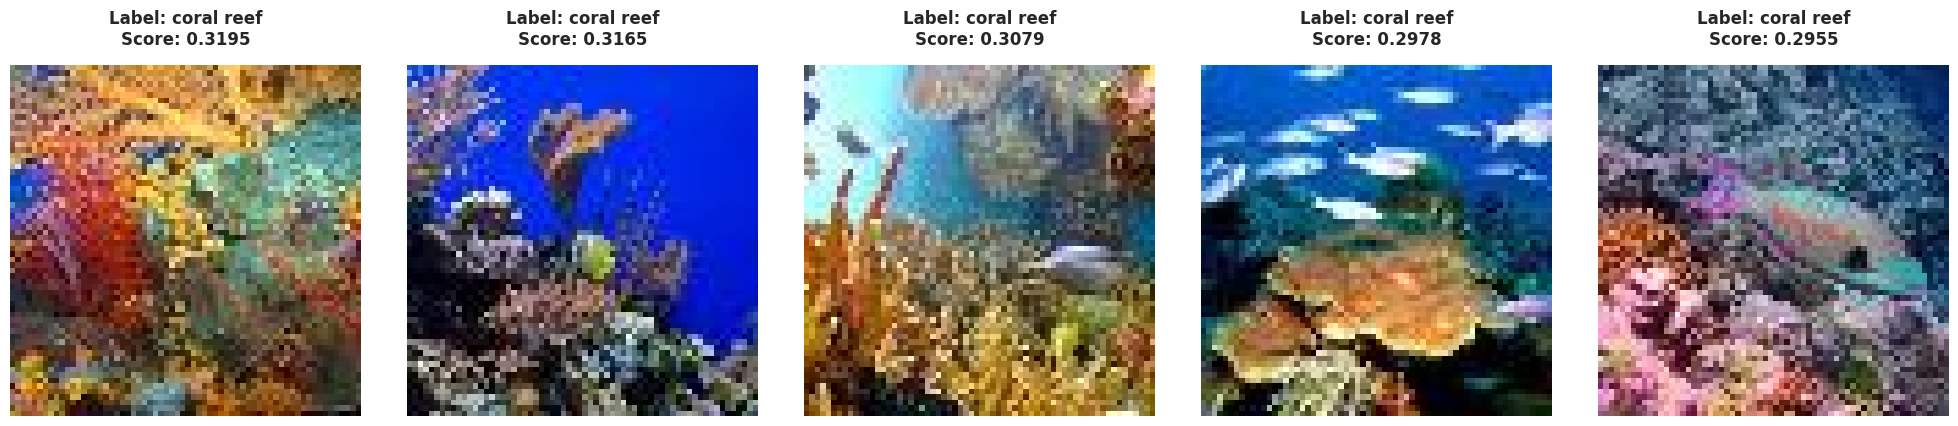

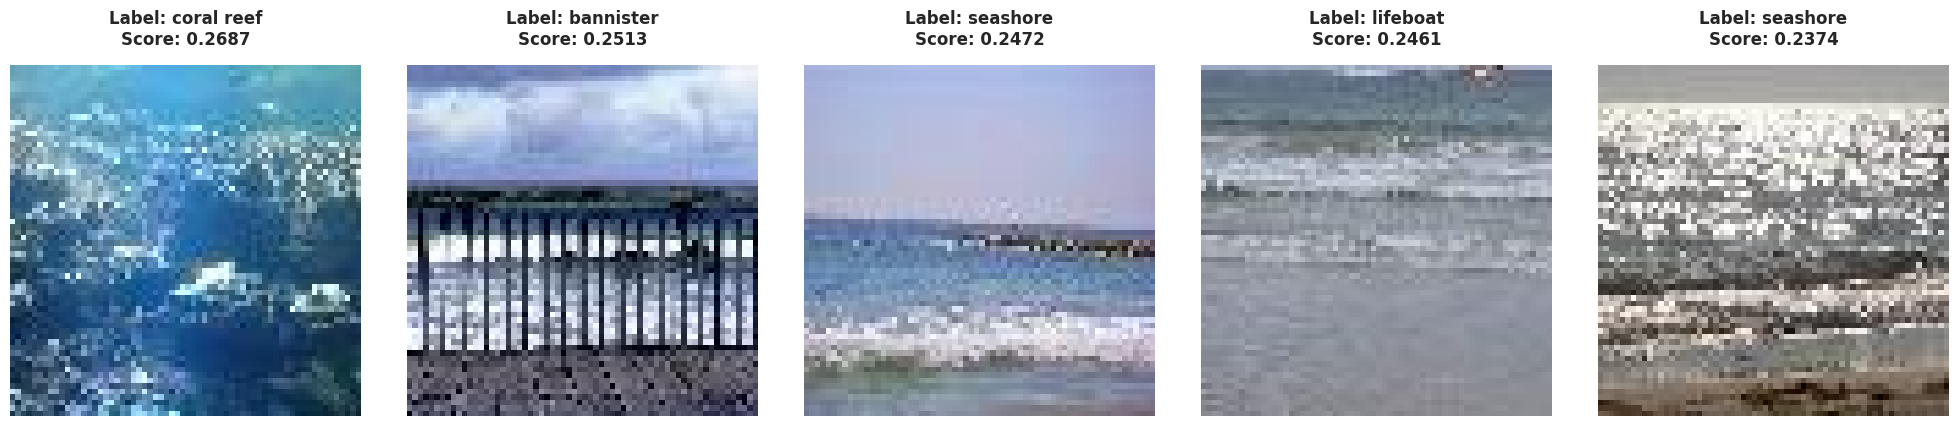

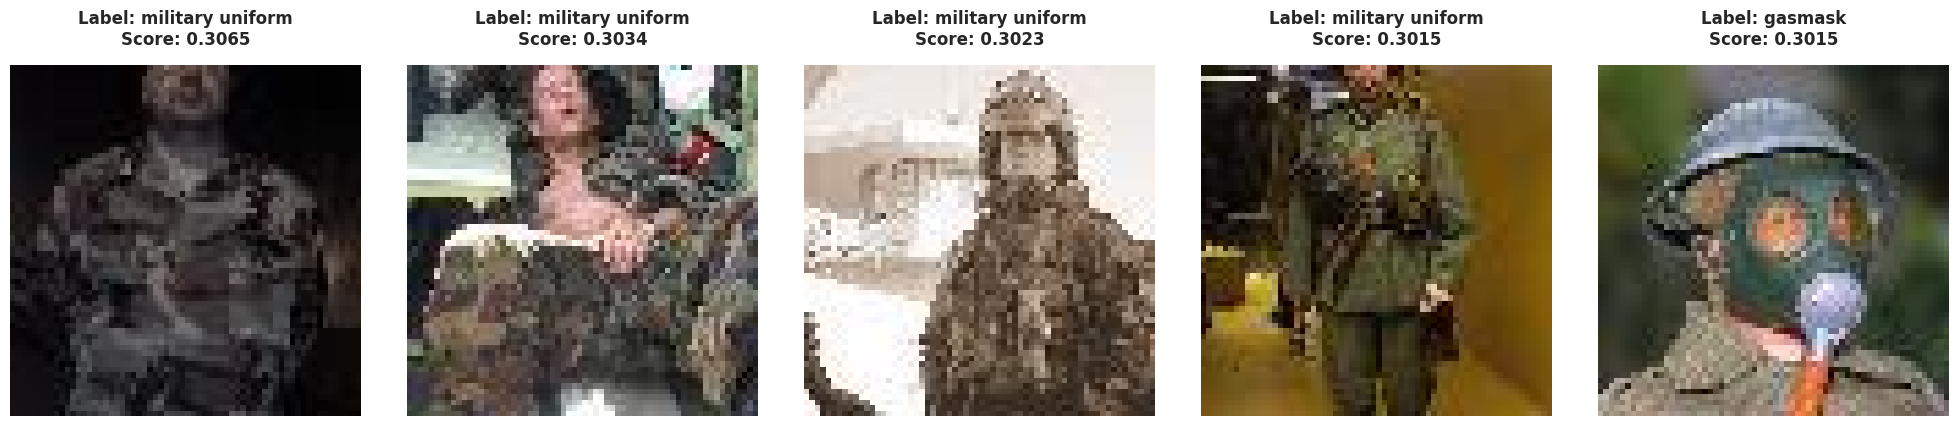

In [33]:
sample_queries = [
    "A red car",
    "A vivid green forest",
    "A colourful coral reef",
    "A wide ocean",
    "A military"
]

for q in sample_queries:
    scores, indices = text_image(q, model, processor, device, embeddings_tensor)
    visualise_search(dataset, scores, indices, query_txt = q)

#### Image to Image

Here, instead of relying on web URLs which can suffer from broken links or HTTP blocking, I simply clone a custom GitHub repository directly in the notebook environment. We then load 5 external images from this local repo, resize them to 64x64 pixels to then pass them through the search engine. Finally, we visualise the image to image search results.

In [34]:
repo_url = "https://github.com/OskarK16/LMH-Tutorials.git"
repo_dir = "LMH-Tutorials"

if os.path.exists(repo_dir):
    shutil.rmtree(repo_dir)

In [35]:
!git clone {repo_url}

Cloning into 'LMH-Tutorials'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 76 (delta 27), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (76/76), 19.39 MiB | 14.22 MiB/s, done.
Resolving deltas: 100% (27/27), done.


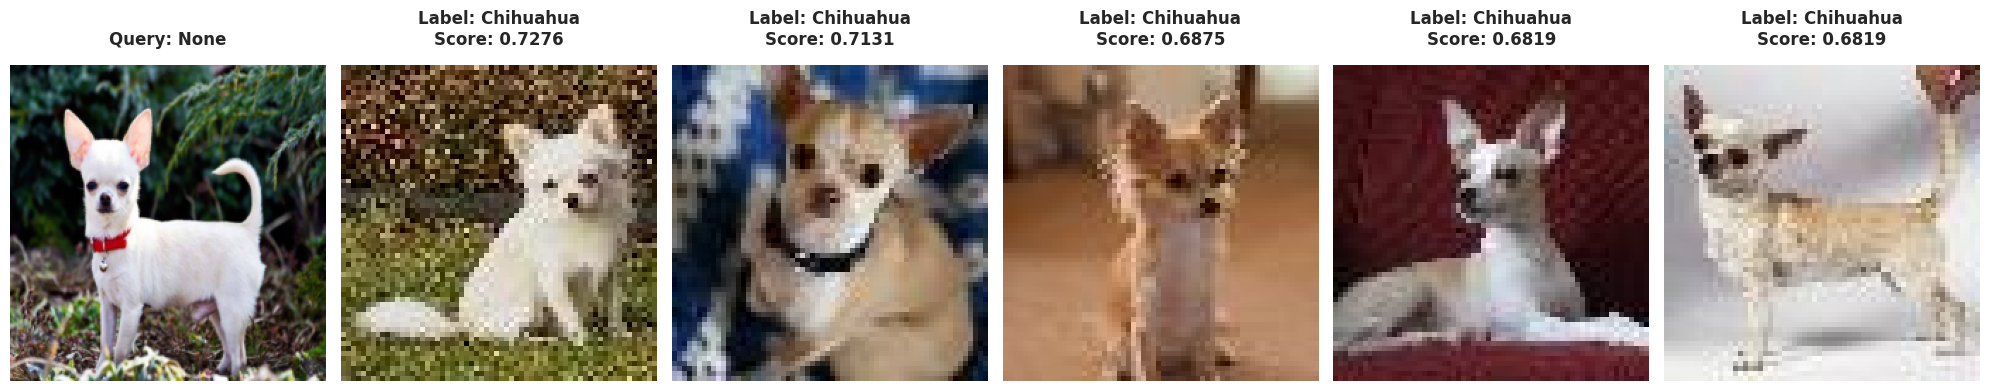

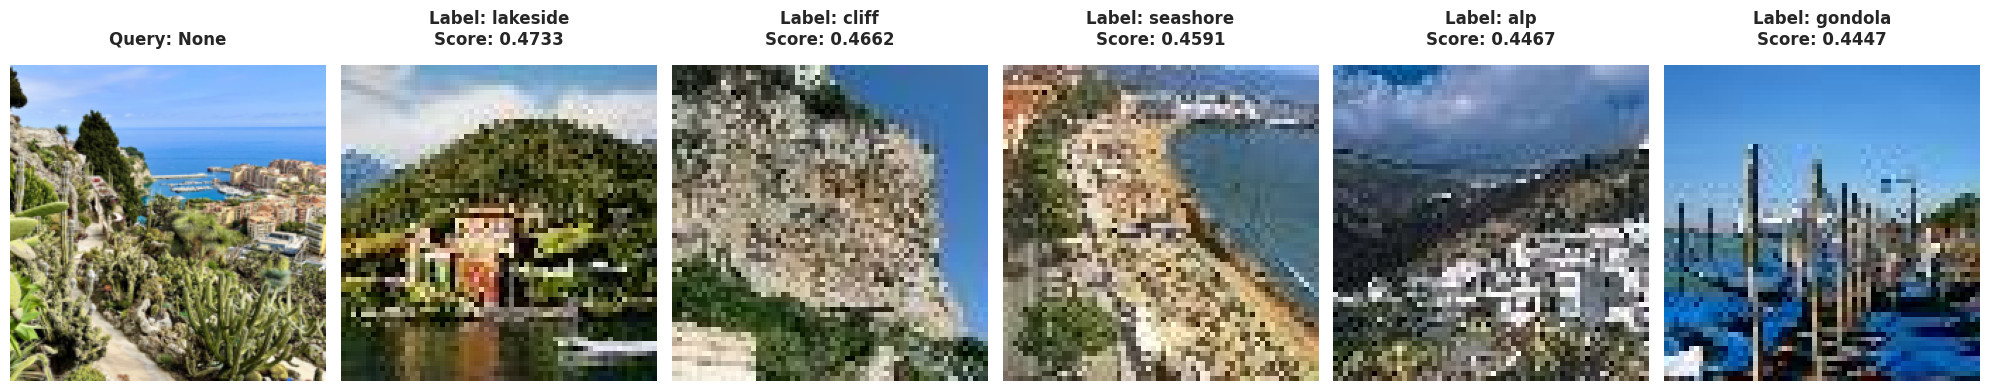

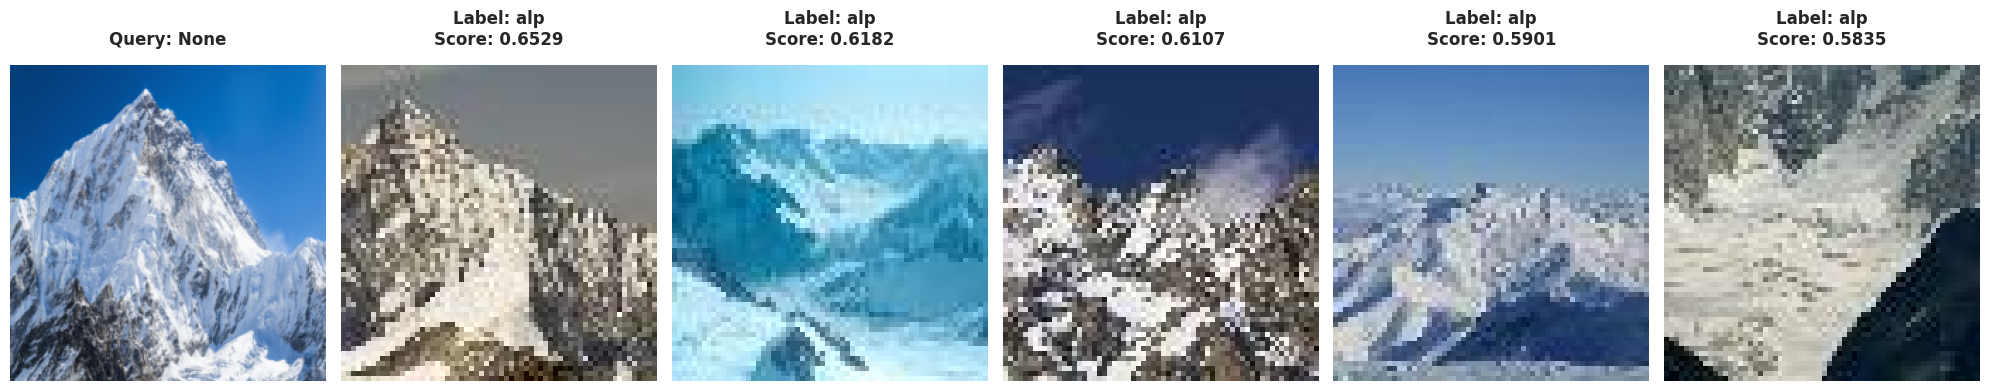

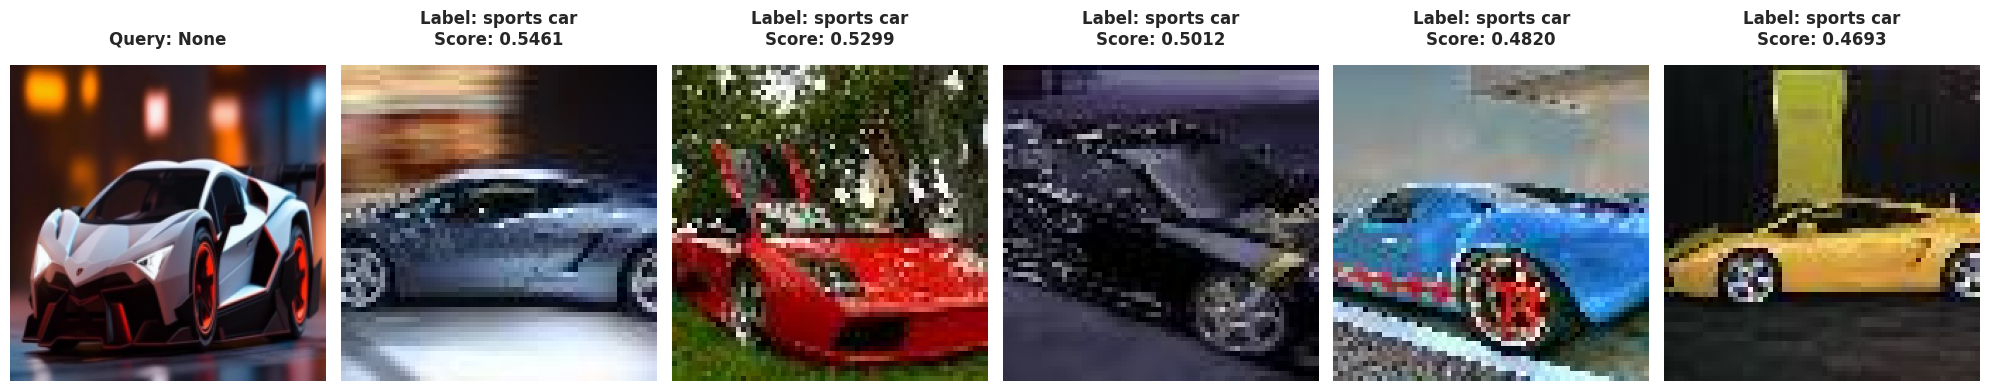

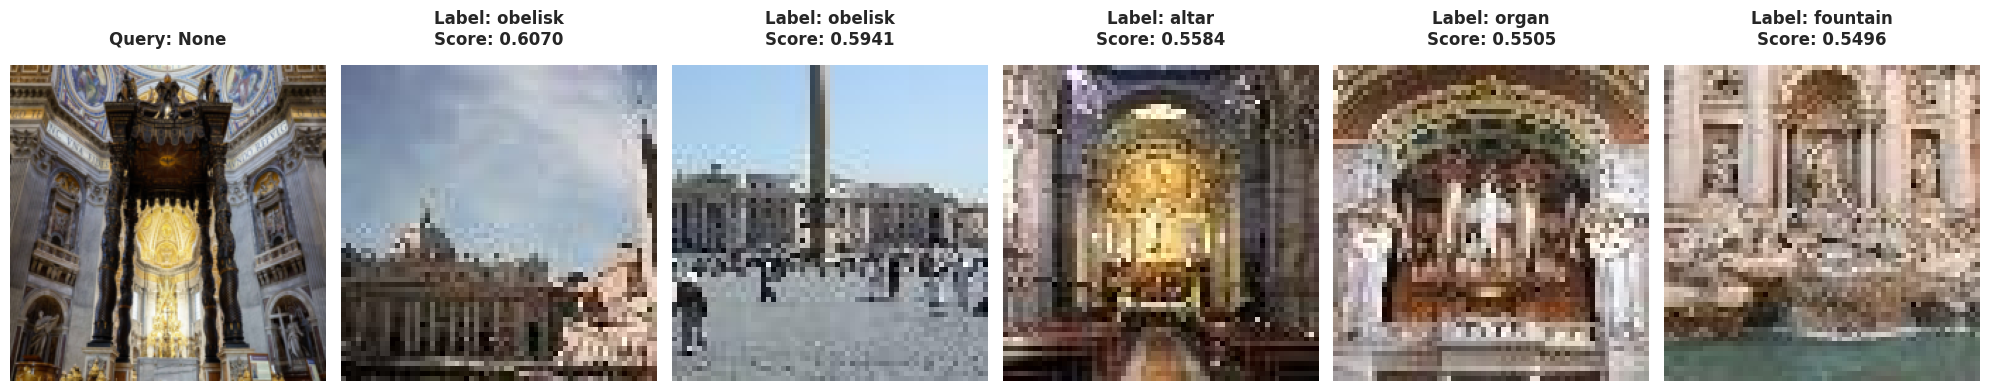

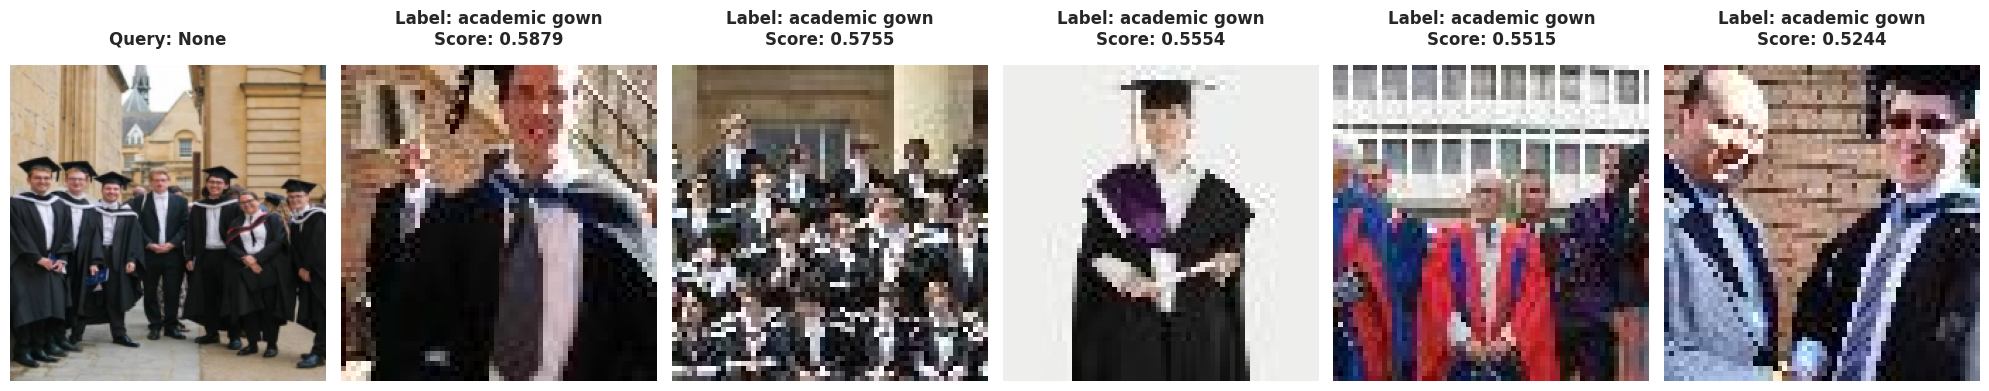

In [36]:
image_paths = [f"{repo_dir}/images/image{i}.jpg" for i in range(1, 7)]
source_image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
])

for path in image_paths:
    name = os.path.basename(path)

    if not os.path.exists(path):
        print("File not found\n")
        continue

    image = Image.open(path).convert("RGB")
    image_tensor = transforms.ToTensor()(image)
    image_tensor = source_image_transform(image_tensor)

    scores, indices = image_image(image_tensor, model, device, embeddings_tensor)
    visualise_search(dataset, scores, indices, query_img = image_tensor)

## References



*   CLIP original paper: https://arxiv.org/pdf/2103.00020
*   Hugging Face documentation: https://huggingface.co/
*   Generative models vidoe: https://www.youtube.com/watch?v=iv-5mZ_9CPY&t=217s
*  CLIP statistics and evaluation: https://medium.com/voxel51/a-history-of-clip-model-training-data-advances-599473b48e1b

---





logo_lg.svg